# Project 2 — Geospatial Hotspot Detection (DBSCAN)

**Business problem:** A ride-share / food-delivery company wants to identify **"hotspot" zones**
where demand (pickup or delivery requests) is naturally concentrated, so it can position drivers
proactively. Real demand hotspots are **never perfectly circular** -- they follow roads,
neighborhoods, and city geography -- which makes this a great real-world fit for DBSCAN instead
of K-Means.

> **Note on data:** This notebook generates **synthetic GPS ping data** around a few simulated
> hotspot zones (using latitude/longitude-like coordinates), since this environment has no
> internet access to pull real ride-share data. If you have a real GPS ping dataset (columns like
> `latitude`, `longitude`), just swap the "Generate synthetic data" cell for `pd.read_csv(...)`
> and the rest of the notebook works unchanged.


## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

np.random.seed(5)
plt.rcParams['figure.figsize'] = (8, 7)


## 2. Generate / Load the Dataset

In [2]:
# ---- Synthetic GPS pings around a few demand hotspots, plus scattered noise pings ----
# (lat, lon, number_of_pings) for each simulated hotspot -- e.g., business districts, malls, stations
hotspots = [
    (28.61, 77.23, 60),   # e.g., a busy downtown area
    (28.70, 77.10, 50),   # e.g., a residential/business hub
    (28.55, 77.30, 45),   # e.g., a shopping district
    (28.65, 77.20, 40),   # e.g., a transit station area
]

rows = []
for lat, lon, n in hotspots:
    pings = np.random.normal([lat, lon], 0.008, size=(n, 2))
    rows.append(pings)

# Scattered, one-off pings with no real "hotspot" (e.g., isolated home deliveries)
scattered = np.random.uniform([28.45, 77.0], [28.8, 77.4], size=(15, 2))
rows.append(scattered)

X = np.vstack(rows)
df = pd.DataFrame(X, columns=['latitude', 'longitude'])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df.head()


,latitude,longitude
0,28.606514,77.237777
1,28.648077,77.199702
2,28.697592,77.091053
3,28.602509,77.279667
4,28.711606,77.104855


## 3. Visualize the Raw Pings

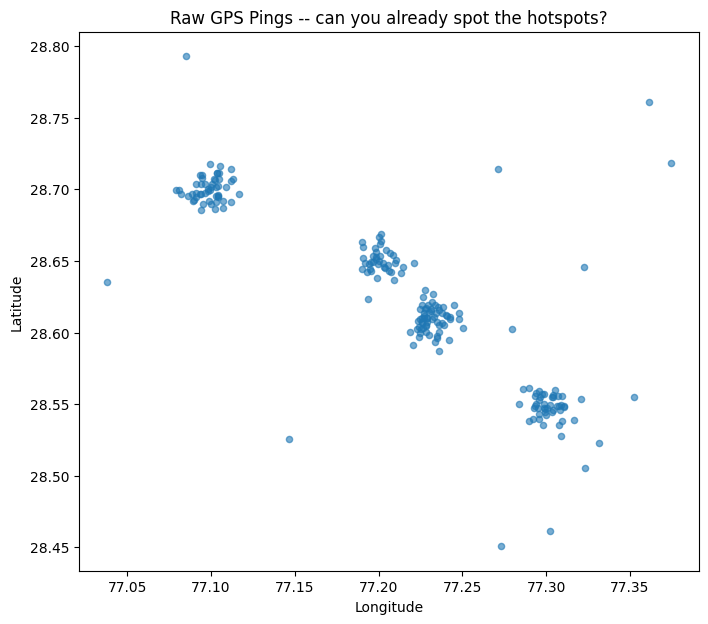

In [3]:
plt.scatter(df['longitude'], df['latitude'], alpha=0.6, s=20)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Raw GPS Pings -- can you already spot the hotspots?')
plt.show()


## 4. Feature Scaling

Latitude and longitude are already on a roughly comparable numeric scale, but we standardize
anyway -- this is good practice for any distance-based clustering, and matters more once you add
other features (e.g., time of day, order value) alongside coordinates.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['latitude', 'longitude']])


## 5. Choose Epsilon

In [5]:
for eps_try in [0.15, 0.3, 0.5, 0.7, 1.0]:
    db_try = DBSCAN(eps=eps_try, min_samples=8).fit(X_scaled)
    n_clusters = len(set(db_try.labels_)) - (1 if -1 in db_try.labels_ else 0)
    n_noise = (db_try.labels_ == -1).sum()
    print(f"eps={eps_try:.2f} -> hotspots found={n_clusters}, scattered/noise pings={n_noise}")


eps=0.15 -> hotspots found=4, scattered/noise pings=17
eps=0.30 -> hotspots found=3, scattered/noise pings=13
eps=0.50 -> hotspots found=3, scattered/noise pings=9
eps=0.70 -> hotspots found=2, scattered/noise pings=9
eps=1.00 -> hotspots found=2, scattered/noise pings=7


`eps=0.15` (on the scaled data) gives 4 clean hotspots, matching our 4 simulated demand centers, with the scattered one-off pings correctly excluded as noise.

## 6. Apply DBSCAN

In [6]:
dbscan = DBSCAN(eps=0.15, min_samples=8)
df['hotspot'] = dbscan.fit_predict(X_scaled)

n_hotspots = len(set(df['hotspot'])) - (1 if -1 in df['hotspot'].values else 0)
print(f"Identified {n_hotspots} hotspot zones.")
print(f"{(df['hotspot'] == -1).sum()} pings classified as scattered/one-off (noise).")


Identified 4 hotspot zones.
17 pings classified as scattered/one-off (noise).


## 7. Visualize the Hotspots on a Map-Style Scatter Plot

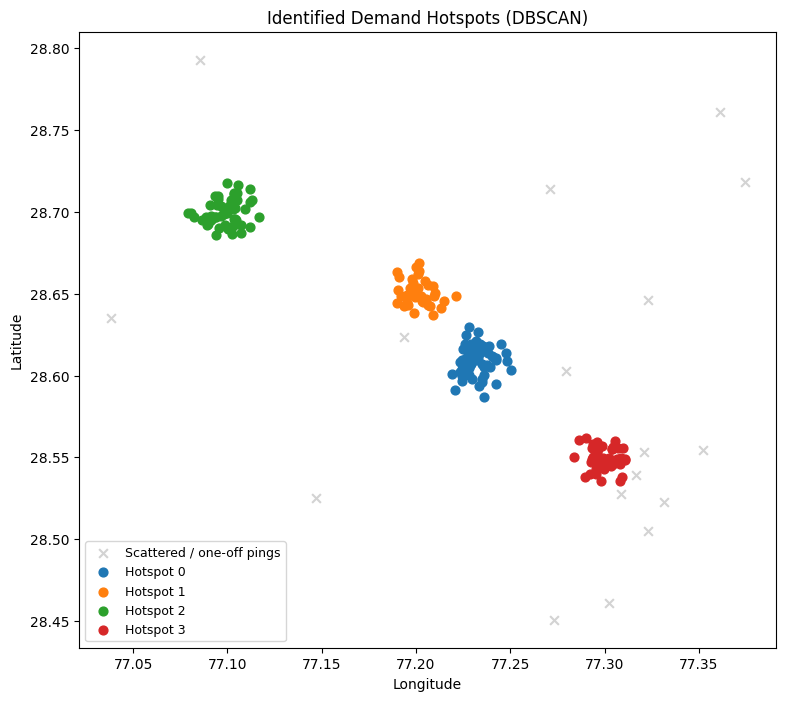

In [7]:
fig, ax = plt.subplots(figsize=(9, 8))

noise_mask = df['hotspot'] == -1
ax.scatter(df.loc[noise_mask, 'longitude'], df.loc[noise_mask, 'latitude'],
           c='lightgray', marker='x', s=40, label='Scattered / one-off pings')

for hs in sorted(df['hotspot'].unique()):
    if hs == -1:
        continue
    mask = df['hotspot'] == hs
    ax.scatter(df.loc[mask, 'longitude'], df.loc[mask, 'latitude'],
               s=40, label=f'Hotspot {hs}')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Identified Demand Hotspots (DBSCAN)')
ax.legend(loc='best', fontsize=9)
plt.show()


## 8. Business Interpretation

In [8]:
hotspot_summary = df[df['hotspot'] != -1].groupby('hotspot')[['latitude', 'longitude']].agg(['mean', 'count'])
hotspot_summary


latitude        longitude      
              mean count       mean count
hotspot                                  
0        28.609050    61  77.231981    61
1        28.650748    39  77.201154    39
2        28.700120    51  77.099142    51
3        28.549430    42  77.299749    42

**How an operations team would use this:** Each identified hotspot's center coordinates tell
the company **where to pre-position drivers or delivery riders** ahead of expected demand, and the
ping counts per hotspot indicate **relative demand intensity** -- helping prioritize which zones
get more resources. The scattered/noise pings are one-off requests that don't justify dedicated
positioning -- exactly the kind of distinction K-Means (which would force every point into some
cluster) could not make.

## 9. Try It Yourself

- Add a `time_of_day` feature and see if hotspots shift between morning/evening.
- Try `min_samples` values of 5, 10, and 15 -- how sensitive are the results?
- Overlay this on a real map (e.g., using `folium` or `plotly`) if you have real GPS data.
